In [66]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [67]:
df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

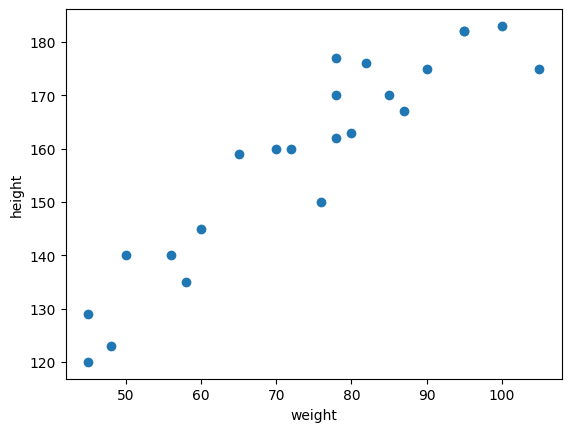

In [68]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("weight")
plt.ylabel("height")

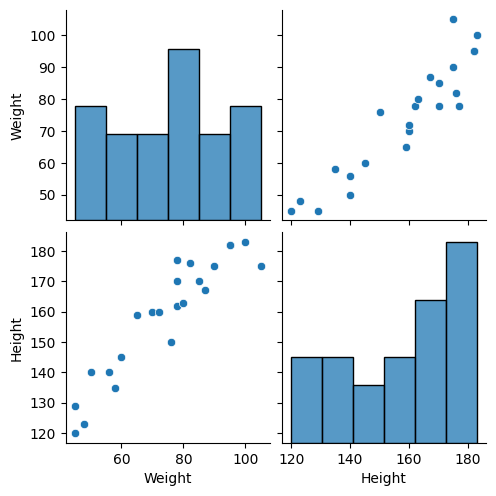

In [69]:
sns.pairplot(df)

In [70]:
corr=df.corr()
print(corr)

          Weight    Height
Weight  1.000000  0.931142
Height  0.931142  1.000000


In [71]:
x=df[["Weight"]]
y=df["Height"]

In [72]:
from sklearn.model_selection import train_test_split

x_train,x_tests,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
print(x.shape)
print(x_train.shape)

(23, 1)
(18, 1)


In [74]:
from sklearn.preprocessing import StandardScaler
scalar= StandardScaler()

x_train=scalar.fit_transform(x_train)
x_tests=scalar.transform(x_tests)

In [75]:
from sklearn.linear_model import LinearRegression

regression=LinearRegression()

regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
slope= regression.coef_
intercept=regression.intercept_

In [77]:
#prediction on test value
y_pred=regression.predict(x_tests)

In [78]:
#performance
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

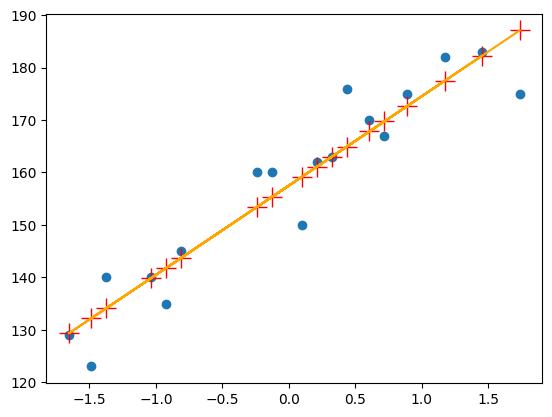

In [79]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train),"r+",ms=15)
plt.plot(x_train,regression.predict(x_train),color="orange")

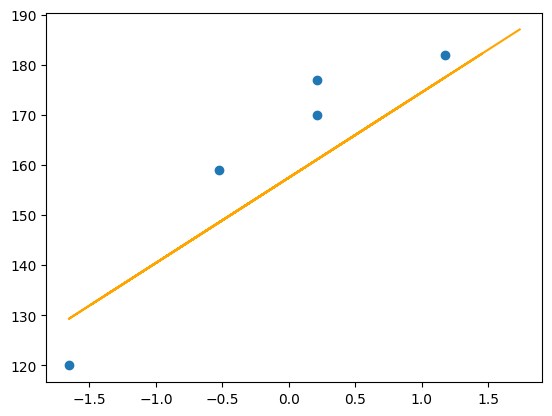

In [81]:
plt.scatter(x_tests,y_test)
plt.plot(x_train,regression.predict(x_train),color="orange")